# Phase 4b — diagnostic workbench: the anchor-rooted descent engine on Daniocell

A **transparent, read-only workbench** for examining exactly how zlabel's deterministic engine
behaves on the Daniocell broad-tissue benchmark — every success and failure mode, drillable down to
individual clusters, with the engine internals on display (no black boxes). It doubles as a
**reusable exploration tool**: the helpers in Sections 6–8 (`inspect`, `show_panel_scores`,
`best_term_at_min`) let you poke at any cluster and preview a tuning lever.

**The eval in three sentences.** Each Daniocell fine cluster's marker genes go into the engine,
which returns a `Label`: a *named* ZFA term, a coarse *panel fallback*, a germ-layer *rollup*, or an
honest *abstention*. We score **broad agreement** — does the predicted anatomy sit at or under the
gold tissue's ZFA anchor (`grounds_under`)? — and run a **parent-child overcall audit**: when the
engine names a specific term, did it win on the bare minimum genes while a broader term had more
support?

**The engine is not changed here.** This is the measurement leg — the support-weighted anchor-rooted
descent in place, scored honestly. Section 7 *previews* the one remaining lever (read-only) to inform
a later 4c. Run top to bottom.

**Roadmap.** §1 load · §2 the outcomes table + headline report · §3 unfold `cluster_outcomes` on one
cluster · §4 unfold the overcall audit · §5 the success/failure modes · §6 aggregate plots ·
§7 a read-only what-if lever · §8 the `inspect` explorer + synthesis.

> Prereqs: the committed `benchmarks/daniocell_eval.csv` (no 2.5 GB download — that is the builder),
> and the `[eval]` extra for pandas (`uv sync --extra eval`). Start the server with `make notebook`
> so the working directory is the repo root.

## 1. Setup — load the benchmark, the crosswalk, and the engine

Everything here reuses the real `zlabel.evaluate` functions (so the notebook can't drift from what
the harness actually does):

- `load_benchmark(csv)` — the benchmark rows (`cluster_id`, `markers`, `broad_tissue`, …).
- `load_crosswalk(yaml)` — the fail-closed `tissue -> broad ZFA anchor(s)` scoring map.
- `load_resources(...)` — the engine's loaded ontologies, panels, and IC model (what a `Labeler`
  holds), so we can label each cluster at its own stage and replay the convergence descent. Its fields:
  `resources.zfa_ontology` / `.expression_map` / `.information_content` / `.panels` / `.synonyms`.

**What to look for:** 522 clusters, 33 panels, ~3,161 ZFA terms. The benchmark and crosswalk are
small committed files; the resources are the same data a `Labeler` loads.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# rich: pretty.install() makes plain values (lists, dataclasses) render nicely in the REPL;
# Console + Table give us the colour-coded tables this notebook uses throughout.
from rich import pretty
pretty.install()
from rich.console import Console
from rich.markdown import Markdown
from rich.table import Table

from zlabel import evaluate
from zlabel.genes import STATUS_RESOLVED, normalize_markers
from zlabel.panels import score_markers
from zlabel.resolve import CONVERGENCE_MIN, INFORMATION_CONTENT_MIN, resolve_label

console = Console()

# Colour key (used in every rich.Table below):
#   green  = agree / named (a committed, correct, or specific call)
#   yellow = fallback / rollup (a coarse or hedged call)
#   red    = disagree / thin-support overcall (a wrong or over-precise call)
#   dim    = abstain / zero (no call, or an empty cell)

# Resolve the repo root whether the kernel started in the repo or the notebook dir.
ROOT = Path.cwd()
while not (ROOT / "benchmarks" / "daniocell_eval.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "data" / "ontologies"

# Reuse the real evaluate.* loaders, so the notebook can never drift from the harness:
#   load_benchmark  -> the benchmark rows (cluster_id, markers, broad_tissue, stage_hpf, ...)
#   load_crosswalk  -> the fail-closed tissue -> broad ZFA anchor(s) scoring map
#   load_resources  -> the engine's loaded ontologies, panels, and IC model (what a Labeler holds)
benchmark = evaluate.load_benchmark(ROOT / "benchmarks" / "daniocell_eval.csv")
crosswalk = evaluate.load_crosswalk(ROOT / "benchmarks" / "daniocell_tissue_crosswalk.yaml")
resources = evaluate.load_resources(
    zfa_path=DATA / "zfa.obo",
    expr_path=DATA / "zfin_wildtype_expression.txt",
    gaf_path=DATA / "zfin.gaf",
    panels_path=ROOT / "src" / "zlabel" / "panels.yaml",
)
print(f"{len(benchmark)} benchmark clusters · {len(resources.panels)} panels · ZFA {resources.zfa_ontology.number_of_nodes():,} terms")

522 benchmark clusters · 33 panels · ZFA 3,161 terms


**What to look for:** one example benchmark row (its gold tissue, stage, and first markers), then the
crosswalk — each gold tissue maps to one or more broad ZFA anchors a prediction must ground under to
"agree". `blas` (blastomeres) is `not_scored`: it has no meaningful broad-tissue anatomy anchor.

In [2]:
# One example row: the benchmark gives us markers + a gold broad-tissue code + a developmental stage.
example_row = benchmark[0]
print("benchmark columns : cluster_id, markers, broad_tissue, tissue_name, stage_hpf")
print(f"example row       : {example_row.cluster_id}  ·  gold tissue: {example_row.broad_tissue} "
      f"({example_row.tissue_name})  ·  stage: {example_row.stage_hpf} hpf")
print(f"first markers     : {example_row.markers[:5]}")

# The crosswalk: gold tissue -> the broad ZFA anchor(s) a prediction must sit under to "agree".
# Render it as a rich.Table; the one not_scored tissue (blastomeres) is dimmed.
xwalk = Table(title="crosswalk: gold tissue -> broad ZFA anchors (fail-closed)", title_style="bold")
xwalk.add_column("tissue", style="cyan")
xwalk.add_column("broad ZFA anchors")
xwalk.add_column("scored?", justify="center")
for tissue in sorted(crosswalk.anchors):
    xwalk.add_row(tissue, ", ".join(sorted(crosswalk.anchors[tissue])), "[green]yes[/]")
for tissue in sorted(crosswalk.not_scored):
    xwalk.add_row(f"[dim]{tissue}[/]", "[dim]— (no broad anchor)[/]", "[dim]no[/]")
console.print(xwalk)

benchmark columns : cluster_id, markers, broad_tissue, tissue_name, stage_hpf
example row       : axia.1  ·  gold tissue: axia (axial)  ·  stage: 36.0 hpf
first markers     : ['si:ch73-23l24.1', 'col9a1b', 'col2a1a', 'col11a1a', 'col9a2']


 crosswalk: gold tissue -> broad ZFA anchors (fail-closed)  
┏━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ tissue ┃ broad ZFA anchors                     ┃ scored? ┃
┡━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ axia   │ ZFA:0001204                           │   yes   │
│ ceph   │ ZFA:0000113                           │   yes   │
│ endo   │ ZFA:0000017, ZFA:0000339              │   yes   │
│ epid   │ ZFA:0000105, ZFA:0000368              │   yes   │
│ eye    │ ZFA:0000107                           │   yes   │
│ fin    │ ZFA:0000108                           │   yes   │
│ glia   │ ZFA:0009073                           │   yes   │
│ hema   │ ZFA:0000007, ZFA:0001159, ZFA:0005023 │   yes   │
│ iono   │ ZFA:0005323                           │   yes   │
│ mese   │ ZFA:0000393                           │   yes   │
│ mura   │ ZFA:0005944                           │   yes   │
│ musc   │ ZFA:0000548                           │   yes   │
│ neur   │ ZFA:0000396                           │   yes   │
│ otic   │ ZFA:0000051, ZFA:0000217              │   yes   │
│ peri   │ ZFA:0001185                           │   yes   │
│ pgc    │ ZFA:0009288                           │   yes   │
│ pigm   │ ZFA:0009090                           │   yes   │
│ pron   │ ZFA:0000151                           │   yes   │
│ tast   │ ZFA:0000034, ZFA:0001074              │   yes   │
│ blas   │ — (no broad anchor)                   │   no    │
└────────┴───────────────────────────────────────┴─────────┘

## 2. The per-cluster outcomes table — the artifact we explore

`evaluate.cluster_outcomes()` labels and scores **every** cluster and returns one `ClusterOutcome`
each (Section 3 unfolds what it does internally). This is exactly the per-cluster data the headline
report aggregates — same numbers, no black box. We keep a `pandas` DataFrame because Section 6's
matplotlib plots need one, but render the *head* as a colour-coded `rich.Table` and reconcile the
key counts so every later number lands on the same denominator.

**Denominators, pinned once here** (they recur throughout): **522** clusters total; **11** are
`not_scored` (the `blas` blastomere tissue has no broad anchor); the remaining **511** are *scored*,
and that 511 is the denominator for the kind split, the abstain-reason split, and coverage.

In [3]:
# Label + score every cluster once. cluster_outcomes returns one ClusterOutcome per cluster;
# we also keep a by-id dict so any drill-down can grab the full object instantly.
outcomes = evaluate.cluster_outcomes(benchmark, crosswalk, resources)
oc = {o.cluster_id: o for o in outcomes}  # by-id lookup for drill-downs (keeps the full objects)

# Flatten to a DataFrame: Section 6's matplotlib plots need one, and it is handy for filtering.
df = pd.DataFrame([{
    "cluster_id": o.cluster_id,
    "gold_tissue": o.gold_tissue,
    "tissue_name": o.tissue_name,
    "kind": o.kind,                 # named | fallback | rollup | abstain
    "bucket": o.bucket,             # the call (named ZFA term, or coarse panel bucket)
    "panel_bucket": o.panel_bucket, # the coarse prior
    "depth": o.depth,
    "scored": o.scored,             # False for not_scored gold tissues (e.g. blastomeres)
    "agrees": o.agrees,             # True/False for scored named+fallback; None otherwise
    "confidence": o.confidence,
    "abstain_reason": o.abstain_reason,  # no_panel | weak_signal | mixed | None
    "n_resolved": o.n_resolved,     # markers that resolved to a current ZFIN symbol
    "n_convergent": len(o.convergent_genes),
    "support_fraction": o.audit.support_fraction if o.audit else None,
    "thin_overcall": o.audit.thin_support_overcall if o.audit else None,
} for o in outcomes])

# ---- Count reconciliation (every later denominator descends from these) -------------------------
total = len(outcomes)
scored = int(df["scored"].sum())
not_scored = total - scored
sdf = df[df["scored"]]
kind_counts = sdf["kind"].value_counts()
n_named, n_fallback = int(kind_counts.get("named", 0)), int(kind_counts.get("fallback", 0))
n_rollup, n_abstain = int(kind_counts.get("rollup", 0)), int(kind_counts.get("abstain", 0))
# Two independent views of "abstain" must agree over the SAME (scored) denominator:
#   (a) kind == "abstain", and (b) a non-None abstain_reason. They are the same clusters.
n_abstain_reason = int(sdf["abstain_reason"].notna().sum())
assert n_named + n_fallback + n_rollup + n_abstain == scored, "kind split must cover all scored clusters"
assert n_abstain == n_abstain_reason, "abstain-by-kind must equal abstain-by-reason (same denominator)"
print(f"reconciliation OK: total={total}  not_scored={not_scored}  scored={scored}")
print(f"  scored kinds -> named={n_named}  fallback={n_fallback}  rollup={n_rollup}  abstain={n_abstain}")
print(f"  abstain cross-check: kind=='abstain' ({n_abstain}) == non-None abstain_reason ({n_abstain_reason})")

# Colour-coded head: kind drives the row colour (green named / yellow fallback / dim abstain),
# and agree is green-true / red-false / dim-None.
head = Table(title=f"cluster_outcomes head ({df.shape[0]} rows x {df.shape[1]} cols)", title_style="bold")
for col in ("cluster_id", "gold", "kind", "bucket (the call)", "agree", "conf", "abstain_reason", "n_conv"):
    head.add_column(col)
_kind_colour = {"named": "green", "fallback": "yellow", "rollup": "yellow", "abstain": "dim"}
for o in outcomes[:8]:
    colour = _kind_colour[o.kind]
    agree_cell = "[green]True[/]" if o.agrees else "[red]False[/]" if o.agrees is False else "[dim]—[/]"
    head.add_row(
        o.cluster_id, o.gold_tissue, f"[{colour}]{o.kind}[/]", f"[{colour}]{o.bucket}[/]",
        agree_cell, o.confidence or "[dim]—[/]", o.abstain_reason or "[dim]—[/]", str(len(o.convergent_genes)),
    )
console.print(head)

reconciliation OK: total=522  not_scored=11  scored=511
  scored kinds -> named=36  fallback=1  rollup=29  abstain=445
  abstain cross-check: kind=='abstain' (445) == non-None abstain_reason (445)


                         cluster_outcomes head (522 rows x 15 cols)                         
┏━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ cluster_id ┃ gold ┃ kind    ┃ bucket (the call) ┃ agree ┃ conf ┃ abstain_reason ┃ n_conv ┃
┡━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ axia.1     │ axia │ abstain │ mixed/unresolved  │ —     │ —    │ weak_signal    │ 0      │
│ axia.10    │ axia │ abstain │ mixed/unresolved  │ —     │ —    │ no_panel       │ 0      │
│ axia.11    │ axia │ abstain │ mixed/unresolved  │ —     │ —    │ no_panel       │ 0      │
│ axia.12    │ axia │ abstain │ mixed/unresolved  │ —     │ —    │ mixed          │ 0      │
│ axia.13    │ axia │ abstain │ mixed/unresolved  │ —     │ —    │ weak_signal    │ 0      │
│ axia.14    │ axia │ abstain │ mixed/unresolved  │ —     │ —    │ no_panel       │ 0      │
│ axia.15    │ axia │ abstain │ mixed/unresolved  │ —     │ —    │ no_panel       │ 0      │
│ axia.16    │ axia │ abstain │ mixed/unresolved  │ —     │ —    │ weak_signal    │ 0      │
└────────────┴──────┴─────────┴───────────────────┴───────┴──────┴────────────────┴────────┘

**Columns to know:** `kind` is how the engine resolved the cluster; `agrees` is broad-tissue
correctness (only meaningful for assigned named/fallback calls — `None` for abstain/rollup);
`abstain_reason` decomposes *why* an abstention happened; `support_fraction`/`thin_overcall` come
from the overcall audit on named calls.

**What to look for (headline report):** built fresh below from `evaluate.evaluate(...)` +
`render_report(...)` so it can never drift from a stale string. Read it top-down — 522 clusters /
511 scored; **broad agreement 70.3% (26/37)**; coverage **12.9%** (named **36**, fallback **1**,
rollup **29**); **abstain 87.1%**; and the overcall audit (**1 of 36** named calls is thin-support).

In [4]:
# Generate the markdown report INLINE from the live objects (never a pre-baked string):
#   evaluate(...)      -> aggregates the same cluster_outcomes into a Report
#   render_report(...) -> the deterministic markdown the CLI / harness also emits
# display() routes the rich Markdown renderable through Jupyter's display hook.
report = evaluate.evaluate(benchmark, crosswalk, resources)
display(Markdown(evaluate.render_report(report, top_n=8)))

Daniocell baseline report (anchor-rooted descent engine)                              

 • clusters: 522  ·  scored: 511  ·  not_scored: 11                                                                

Broad agreement (named + fallback, scored against the gold tissue)                                                 

 • agreement: 70.3% (26/37)                                                                                        

Coverage / split (over scored clusters)                                                                            

 • coverage (non-abstain): 12.9% (66/511)                                                                          
 • named: 7.0% (36/511)                                                                                            
 • fallback: 0.2% (1/511)                                                                                          
 • rollup: 5.7% (29/511)                                                                                           
 • abstain: 87.1% (445/511)                                                                                        

Agreement by prediction class                                                                                      

 • named: 69.4% (25/36)                                                                                            
 • fallback: 100.0% (1/1)                                                                                          

Confidence by correctness (named + fallback)                                                                       

 • high: 100.0% (12/12)                                                                                            
 • medium: 60.9% (14/23)                                                                                           
 • low: 0.0% (0/2)                                                                                                 

Parent-child overcall audit (named calls)                                                                          

 • named calls audited: 36                                                                                         
 • won with exactly CONVERGENCE_MIN=3 genes: 2.8% (1/36)                                                           
 • thin-support overcalls (won at min, broader parent had more support): 2.8% (1/36)                               

Lowest support-fraction named calls (child support / best-parent support), top 8:                                  

 • musc.19: segmental plate (3) vs portion of tissue (19)  -> fraction 0.16                                        
 • mura.3: mesenchyme (7) vs portion of tissue (20)  -> fraction 0.35                                              
 • mese.5: head mesenchyme (8) vs portion of tissue (22)  -> fraction 0.36                                         
 • eye.30: retinal ganglion cell layer (7) vs compound organ (18)  -> fraction 0.39                                
 • hema.27: nucleate erythrocyte (8) vs hematopoietic system (17)  -> fraction 0.47                                
 • neur.12: diencephalon (9) vs cavitated compound organ (19)  -> fraction 0.47                                    
 • endo.23: exocrine pancreas (7) vs compound organ (14)  -> fraction 0.50                                         
 • neur.33: diencephalon (10) vs cavitated compound organ (20)  -> fraction 0.50                                   

Failure gallery (scored disagreements)                                                                             

 • eye.22: gold eye, predicted 'pigment cell' (named)                                                              
 • glia.11: gold glia, predicted 'diencephalon' (named)                                                            
 • mura.3: gold mura, predicted 'mesenchyme' (named)                                                               
 • musc.19: gold musc, predicted 'segmental plate' (named)            

## 3. Unfolding `cluster_outcomes` — the keystone, one cluster at a time

`cluster_outcomes()` is the black box behind every number above. For each row it runs a fixed
per-cluster pipeline and packs the result into a `ClusterOutcome`. Here is that pipeline, the same
steps `cluster_outcomes` runs internally (and the same ones `Labeler.label` runs, at the row's
stage):

1. **gold anchors** — `crosswalk.gold(tissue)` (the broad ZFA target, or `None` if not_scored).
2. **normalize** — `normalize_markers(markers, synonyms)`; keep `STATUS_RESOLVED` symbols.
3. **score panels** — `score_markers(...)` → the coarse prior + germ-layer guardrail.
4. **decide** — `decide(...)` at the row's `stage_hpf` (= `Labeler.label` at that stage): runs the
   anchor-rooted descent (the guardrail is intrinsic), returns a `Label`.
5. **classify kind** — `named` (the descent named a term) · `fallback` (the descent found nothing) · `rollup`
   (germ-layer tie) · `abstain`.
6. **score agreement** — take the prediction's ZFA anchor and ask `grounds_under(anchor, gold)`.
7. **overcall audit** — for a named call, compare its support to its best-supported ancestor.

We walk all seven on one representative cluster, **then assert the result matches the
`ClusterOutcome` the library already returned** for that cluster — proving the notebook reproduces
the harness, not a hand-rolled approximation.

**What to look for:** each stage's output, then a green `reproduces library ClusterOutcome` check
where our hand-walked `kind` / `bucket` / `agrees` / audit equal `oc[cluster_id]`'s fields.

In [5]:
# Internal pieces cluster_outcomes uses; importing them lets us reproduce it stage by stage.
from zlabel.label import decide
from zlabel.ground import grounds_under

# Pick a clear example: a named call that still lands in the right broad tissue, else any agreer.
named_ok = [o for o in outcomes if o.kind == "named" and o.agrees]
example = (named_ok or [o for o in outcomes if o.agrees] or outcomes)[0]
row = next(b for b in benchmark if b.cluster_id == example.cluster_id)
print(f"cluster {row.cluster_id}  ·  gold tissue: {row.broad_tissue}  ·  stage: {row.stage_hpf} hpf")
print("raw markers (top 8):", row.markers[:8])

# Stage 1 — gold anchors for this tissue (None would mean not_scored).
gold = crosswalk.gold(row.broad_tissue)
print(f"\n[gold]   broad ZFA anchor(s) for {row.broad_tissue!r}: {sorted(gold) if gold else None}")

# Stage 2 — normalize every marker to its current ZFIN symbol (aliases/paralogs resolved).
normalized_markers = normalize_markers(row.markers, resources.synonyms)
symbols = [next(iter(nm.symbols)) for nm in normalized_markers if nm.status == STATUS_RESOLVED]
print(f"[normalize] {len(symbols)}/{len(row.markers)} markers resolved -> e.g. {symbols[:6]}")

# Stage 3 — score the curated panels (the coarse prior + germ-layer guardrail).
scores = score_markers(normalized_markers, resources.panels)
print("\n[score_markers] top panels:")
for bs in scores[:3]:
    print(f"    {bs.bucket:<16} score={bs.score:.3f}  kind={bs.kind}  matched={[m.symbol for m in bs.matched_markers][:4]}")

# Stage 4 — decide() at THIS row's stage (== Labeler.label at that stage). This is where the
# support-weighted anchor-rooted descent (resolve_label) runs, inside the engine.
label = decide(
    scores,
    anchors=resources.anchors,
    expression_map=resources.expression_map,
    zfa_ontology=resources.zfa_ontology,
    stage_hpf=row.stage_hpf,
    symbols=symbols,
    information_content=resources.information_content,
)
# (Peek at the descent the engine ran, for context — seeded at the winning panel's anchor.)
top_identity = next((s for s in scores if s.kind == "identity" and s.score > 0), None)
peek_anchor = resources.anchors.get(top_identity.bucket, frozenset()) if top_identity else frozenset()
votes = resolve_label(symbols, expression_map=resources.expression_map, zfa_ontology=resources.zfa_ontology,
                      information_content=resources.information_content, anchor=peek_anchor)
print("\n[resolve_label] descent terminal term:")
for vote in votes:
    print(f"    {vote.zfa_name:<34} IC={vote.information_content:5.2f}  genes={len(vote.genes)}  {sorted(vote.genes)[:4]}")

# Stage 5 — classify how decide() resolved it (named / fallback / rollup / abstain).
kind = evaluate._classify(label)

# Stage 6 — score broad agreement: does the prediction's ZFA anchor ground under the gold anchor?
pred_ids = evaluate._prediction_anchor_ids(label, kind, resources)
agrees = any(grounds_under(resources.zfa_ontology, pid, gold) for pid in pred_ids) if (gold and pred_ids) else None

# Stage 7 — overcall audit (named calls only): child support vs best-supported ancestor.
audit = evaluate._audit_named(row, label, label.zfa_id, symbols, resources) if (kind == "named" and label.zfa_id) else None

print(f"\n[decide]  -> bucket={label.bucket!r}  kind={kind}  zfa_id={label.zfa_id}  depth={label.depth}  confidence={label.confidence}")
print(f"[score]   -> agrees={agrees}")
if audit:
    print(f"[audit]   -> named {audit.named_support} genes vs parent {audit.parent_name!r} {audit.parent_support}"
          f"  thin_overcall={audit.thin_support_overcall}")

# ---- Proof: our hand-walked pipeline reproduces the library's ClusterOutcome ----
lib = oc[example.cluster_id]
assert (kind, label.bucket, agrees, label.zfa_id, label.depth) == (lib.kind, lib.bucket, lib.agrees, lib.zfa_id, lib.depth)
assert (audit is None) == (lib.audit is None)
if audit is not None:
    assert audit.thin_support_overcall == lib.audit.thin_support_overcall
console.print(f"[green]✓ reproduces library ClusterOutcome[/] for {example.cluster_id}: "
              f"kind={kind}, bucket={label.bucket!r}, agrees={agrees}")

cluster endo.22  ·  gold tissue: endo  ·  stage: 84.0 hpf
raw markers (top 8): ['prss1', 'prss59.2', 'fep15', 'erp27', 'pdia2', 'ctrb1', 'cpb1', 'CELA1 (1 of many)']

[gold]   broad ZFA anchor(s) for 'endo': ['ZFA:0000017', 'ZFA:0000339']
[normalize] 23/25 markers resolved -> e.g. ['prss1', 'prss59.2', 'erp27', 'pdia2', 'ctrb.1', 'cpb1']

[score_markers] top panels:
    pancreas         score=0.178  kind=identity  matched=['prss1', 'cpa5']
    blood_erythroid  score=0.000  kind=identity  matched=[]
    blood_lymphoid   score=0.000  kind=identity  matched=[]

[resolve_label] descent terminal term:
    pancreas                           IC= 5.11  genes=11  ['aqp12', 'cel.1', 'cpa5', 'ctrb.1']

[decide]  -> bucket='pancreas'  kind=named  zfa_id=ZFA:0000140  depth=7  confidence=medium
[score]   -> agrees=True
[audit]   -> named 11 genes vs parent 'compound organ' 14  thin_overcall=False


✓ reproduces library ClusterOutcome for endo.22: kind=named, bucket='pancreas', agrees=True

## 4. Unfolding the overcall audit — what "thin-support overcall" means

Stage 7 above was a one-liner; here is what it does. After the descent names a term, the audit asks a
structural question: **did the winner earn its specificity, or did it stop at a rare term while a
better-supported broad one was right there?**

A **thin-support overcall** is a winner that cleared *exactly* `CONVERGENCE_MIN` genes while a
broader ancestor had *strictly more* support. The descent's relative-support floor is meant to
prevent exactly this; the audit is the regression guard that confirms it, by replaying the raw tally
to see the broad ancestors:

- `evaluate._replay_tally(symbols, expression_map, zfa_ontology)` → `{ZFA term: {genes that credit
  it}}` for **every** term (mirrors the descent's own tally exactly).
- `evaluate._audit_from_tally(...)` → walks the winner's ancestors (stoplist roots excluded), finds
  the best-supported one, and flags `thin_support_overcall = won_at_min AND parent_support > child`.

We trace it on the worst offender (lowest support fraction = child support / best-parent support).

**What to look for:** the named winner credited by exactly 3 genes, a broad ancestor (*portion of
tissue*) credited by ~19, a tiny support fraction, and `thin_support_overcall = True` — the single
such case in the whole benchmark.

In [6]:
from zlabel.data import term_name
from zlabel.resolve import STOPLIST

# The worst overcall = the named call with the lowest child/parent support fraction.
named = [o for o in outcomes if o.kind == "named"]
worst = min(named, key=lambda o: o.audit.support_fraction)
row = next(b for b in benchmark if b.cluster_id == worst.cluster_id)
symbols = [next(iter(nm.symbols)) for nm in normalize_markers(row.markers, resources.synonyms) if nm.status == STATUS_RESOLVED]

# Step 1 — replay the RAW per-term tally (every term, pre-gate). This is what the engine drops.
tally = evaluate._replay_tally(symbols, resources.expression_map, resources.zfa_ontology)

# Step 2 — re-run the audit from that tally (the exact call cluster_outcomes makes internally).
audit = evaluate._audit_from_tally(worst.cluster_id, worst.zfa_id, worst.bucket, tally, resources.zfa_ontology)
assert (audit.support_fraction, audit.thin_support_overcall) == (worst.audit.support_fraction, worst.audit.thin_support_overcall)

# Show the winner against the best-supported ancestors the IC gate hid (excluding stoplist roots),
# so you can see the broad parent the audit found.
ancestor_support = sorted(
    ((tid, len(genes)) for tid, genes in tally.items()
     if tid != worst.zfa_id and tid not in STOPLIST and resources.zfa_ontology.has_node(tid)),
    key=lambda pair: -pair[1],
)
trace = Table(title=f"overcall trace: {worst.cluster_id} (gold {worst.gold_tissue})", title_style="bold")
trace.add_column("role"); trace.add_column("ZFA term"); trace.add_column("genes", justify="right")
# The named winner in red (it is the overcall); the broad parent in yellow; runners-up dim.
trace.add_row("[red]named winner[/]", f"[red]{worst.bucket}[/]", f"[red]{audit.named_support}[/]")
trace.add_row("[yellow]best parent[/]", f"[yellow]{audit.parent_name}[/]", f"[yellow]{audit.parent_support}[/]")
for tid, n in ancestor_support[:5]:
    if tid == audit.parent_id:
        continue
    trace.add_row("[dim]ancestor[/]", f"[dim]{term_name(resources.zfa_ontology, tid) or tid}[/]", f"[dim]{n}[/]")
console.print(trace)

verdict = "[red]thin-support overcall[/]" if audit.thin_support_overcall else "[green]earned[/]"
console.print(
    f"won_at_min={audit.won_at_min} (cleared exactly CONVERGENCE_MIN={CONVERGENCE_MIN}) "
    f"AND parent_support {audit.parent_support} > child {audit.named_support} "
    f"-> support_fraction {audit.support_fraction:.2f} -> {verdict}"
)

       overcall trace: musc.19 (gold musc)       
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ role         ┃ ZFA term               ┃ genes ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ named winner │ segmental plate        │     3 │
│ best parent  │ portion of tissue      │    19 │
│ ancestor     │ organism subdivision   │    21 │
│ ancestor     │ multi-tissue structure │    19 │
│ ancestor     │ head                   │    18 │
│ ancestor     │ compound organ         │    18 │
└──────────────┴────────────────────────┴───────┘

won_at_min=True (cleared exactly CONVERGENCE_MIN=3) AND parent_support 19 > child 3 -> support_fraction 0.16 -> 
thin-support overcall

## 5. The success and failure modes

The headline is honest: the engine **abstains on ~87%** of clusters and agrees ~70% of the time when
it commits. Let's see exactly which clusters fall into each mode and why — this is where fix ideas
come from. Every split below is over the **511 scored** clusters (the `total`, `scored`,
`not_scored` reconciliation from Section 2).

**What to look for:** the kind split — `abstain` dominates (445), `rollup` 29, `named` 36,
`fallback` 1 — and the 26/37 agreement among the 37 assigned (named + fallback) calls.

In [7]:
# The kind split, over the SAME scored denominator reconciled in Section 2.
assigned = sdf[sdf["agrees"].notna()]   # named + fallback that carried a scoreable anchor
n_agree = int(assigned["agrees"].sum())

split = Table(title=f"how the engine resolved each of the {scored} scored clusters", title_style="bold")
split.add_column("kind"); split.add_column("clusters", justify="right"); split.add_column("% of scored", justify="right")
for kind, count, colour in [("named", n_named, "green"), ("fallback", n_fallback, "yellow"),
                            ("rollup", n_rollup, "yellow"), ("abstain", n_abstain, "dim")]:
    split.add_row(f"[{colour}]{kind}[/]", f"[{colour}]{count}[/]", f"[{colour}]{100*count/scored:.1f}%[/]")
console.print(split)
console.print(
    f"broad agreement (named+fallback): [green]{n_agree}[/]/{len(assigned)} "
    f"= {100*n_agree/len(assigned):.0f}% of assigned"
)

 how the engine resolved each of the 
         511 scored clusters         
┏━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ kind     ┃ clusters ┃ % of scored ┃
┡━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ named    │       36 │        7.0% │
│ fallback │        1 │        0.2% │
│ rollup   │       29 │        5.7% │
│ abstain  │      445 │       87.1% │
└──────────┴──────────┴─────────────┘

broad agreement (named+fallback): 26/37 = 70% of assigned

### 5a. Abstentions — *why* the engine declined (the bulk)

`abstain_reason` splits the abstentions three ways: **no_panel** (no curated panel matched the
cluster at all), **weak_signal** (a panel matched but below the signal threshold), **mixed** (top
contenders span contradictory germ layers). The split tells us where the ceiling is.

**What to look for:** the three reasons sum back to the **445** scored abstentions — `weak_signal`
dominates (a panel fired but too faintly), then `no_panel` (no curated panel for that biology), with
a handful of `mixed`. The cell asserts the split equals `n_abstain` from Section 2, so the reason
breakdown and the kind split land on the same denominator.

In [8]:
# Abstain-reason split over the SCORED abstentions (so it reconciles with n_abstain from Section 2).
reason_counts = sdf[sdf["kind"] == "abstain"]["abstain_reason"].value_counts()
assert int(reason_counts.sum()) == n_abstain, "abstain reasons must sum to the abstain kind count"

reasons = Table(title=f"why the {n_abstain} scored abstentions declined", title_style="bold")
reasons.add_column("abstain_reason"); reasons.add_column("clusters", justify="right"); reasons.add_column("% of abstain", justify="right")
for reason in ("weak_signal", "no_panel", "mixed"):
    count = int(reason_counts.get(reason, 0))
    reasons.add_row(f"[dim]{reason}[/]", f"[dim]{count}[/]", f"[dim]{100*count/n_abstain:.1f}%[/]")
console.print(reasons)
print(f"(reconciles: {int(reason_counts.sum())} reasoned abstentions == n_abstain {n_abstain})")

  why the 445 scored abstentions declined   
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ abstain_reason ┃ clusters ┃ % of abstain ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ weak_signal    │      335 │        75.3% │
│ no_panel       │       92 │        20.7% │
│ mixed          │       18 │         4.0% │
└────────────────┴──────────┴──────────────┘

(reconciles: 445 reasoned abstentions == n_abstain 445)


In [9]:
# Panel-coverage ceiling: which gold tissues are most starved of a curated panel?
# no_panel_rate = fraction of a tissue's clusters where EVERY identity panel scored 0.
cov = []
for tissue in sorted(crosswalk.anchors):
    sub = df[df["gold_tissue"] == tissue]
    no_panel_rate = float((sub["abstain_reason"] == "no_panel").mean()) if len(sub) else 0.0
    cov.append((tissue, len(sub), no_panel_rate))
cov.sort(key=lambda r: -r[2])

# Render as rich: redder = more starved (the panels simply cannot touch that biology).
cov_tbl = Table(title="tissues most starved of a matching panel (top 12)", title_style="bold")
cov_tbl.add_column("tissue", style="cyan"); cov_tbl.add_column("clusters", justify="right"); cov_tbl.add_column("no_panel_rate", justify="right")
for tissue, n, rate in cov[:12]:
    colour = "red" if rate >= 0.6 else "yellow" if rate >= 0.3 else "dim"
    cov_tbl.add_row(tissue, str(n), f"[{colour}]{rate:.2f}[/]")
console.print(cov_tbl)

 tissues most starved of a matching  
           panel (top 12)            
┏━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ tissue ┃ clusters ┃ no_panel_rate ┃
┡━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ceph   │        1 │          1.00 │
│ eye    │       41 │          0.41 │
│ musc   │       36 │          0.33 │
│ axia   │       25 │          0.32 │
│ pron   │       17 │          0.29 │
│ neur   │       48 │          0.27 │
│ glia   │       31 │          0.26 │
│ mese   │       33 │          0.21 │
│ endo   │       34 │          0.21 │
│ pigm   │       23 │          0.13 │
│ otic   │       22 │          0.09 │
│ mura   │       24 │          0.08 │
└────────┴──────────┴───────────────┘

**What to look for (drill-down):** one `no_panel` abstention (every identity panel scores 0 — there
is simply no panel for this biology) and one `weak_signal` abstention (a panel *does* score, just
not enough to clear the signal threshold). `show_panel_scores` is one of the reusable explorers
(polished in Section 8); here it confirms the two reasons look different under the hood.

In [10]:
def show_panel_scores(cluster_id, topn=6):
    """Explorer: the identity-panel scores for one cluster, as a colour-coded rich.Table.

    A panel that cleared MIN_SIGNAL (0.15) is green; a non-zero but sub-threshold panel is
    yellow (this is what a weak_signal abstention looks like); a zero panel is dim (no_panel).

    Args:
        cluster_id (str): A benchmark cluster id (e.g. "axia.1").
        topn (int): How many identity panels to show, highest score first.
    """
    o = oc[cluster_id]
    row = next(b for b in benchmark if b.cluster_id == cluster_id)
    scores = [s for s in score_markers(normalize_markers(row.markers, resources.synonyms), resources.panels)
              if s.kind == "identity"]
    tbl = Table(title=f"{cluster_id}  ·  gold {o.gold_tissue}  ·  abstain_reason={o.abstain_reason}", title_style="bold")
    tbl.add_column("panel", style="cyan"); tbl.add_column("score", justify="right"); tbl.add_column("matched markers")
    for s in scores[:topn]:
        colour = "green" if s.score >= 0.15 else "yellow" if s.score > 0 else "dim"
        matched = ", ".join(m.symbol for m in s.matched_markers[:5]) or "[dim]—[/]"
        tbl.add_row(f"[{colour}]{s.bucket}[/]", f"[{colour}]{s.score:.3f}[/]", matched)
    console.print(tbl)

# Contrast the two abstention reasons: no_panel (all zeros) vs weak_signal (a faint hit).
for reason in ("no_panel", "weak_signal"):
    cid = df[df["abstain_reason"] == reason]["cluster_id"].iloc[0]
    show_panel_scores(cid)

          axia.10  ·  gold axia  ·           
           abstain_reason=no_panel           
┏━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ panel           ┃ score ┃ matched markers ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ blood_erythroid │ 0.000 │ —               │
│ blood_lymphoid  │ 0.000 │ —               │
│ cardiac         │ 0.000 │ —               │
│ cartilage       │ 0.000 │ —               │
│ endoderm_gut    │ 0.000 │ —               │
│ endothelium     │ 0.000 │ —               │
└─────────────────┴───────┴─────────────────┘

axia.1  ·  gold axia  ·  abstain_reason=weak_signal 
┏━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ panel           ┃ score ┃ matched markers        ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ notochord       │ 0.132 │ col2a1a, col8a1a, shha │
│ cartilage       │ 0.066 │ col2a1a                │
│ epidermis       │ 0.032 │ krt8                   │
│ blood_erythroid │ 0.000 │ —                      │
│ blood_lymphoid  │ 0.000 │ —                      │
│ cardiac         │ 0.000 │ —                      │
└─────────────────┴───────┴────────────────────────┘

### 5b. Fallback — a panel matched, but the vote named nothing

The cluster scored a panel (so it isn't an abstention), but the anchor-rooted descent found no
supported term under the panel's anchor, so the engine fell back to the coarse panel bucket. These are scored at
the broad level.

**What to look for:** the fallback clusters (the descent named nothing → the coarse panel bucket),
scored at the broad level. Green rows agree with the gold tissue; red rows disagree (the panel prior
pointed at the wrong germ layer).

In [11]:
# Fallback calls (vote named nothing -> coarse panel bucket), coloured by broad agreement.
fb = [o for o in outcomes if o.kind == "fallback"]
fb_agree = sum(1 for o in fb if o.agrees)
tbl = Table(title=f"{len(fb)} fallback clusters · agreement {100*fb_agree/len(fb):.0f}%", title_style="bold")
tbl.add_column("cluster_id"); tbl.add_column("gold"); tbl.add_column("panel bucket (the call)"); tbl.add_column("agree", justify="center")
for o in sorted(fb, key=lambda o: o.cluster_id)[:12]:
    colour = "green" if o.agrees else "red"
    tbl.add_row(o.cluster_id, o.gold_tissue, f"[{colour}]{o.bucket}[/]", f"[{colour}]{o.agrees}[/]")
console.print(tbl)

         1 fallback clusters · agreement 100%          
┏━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ cluster_id ┃ gold ┃ panel bucket (the call) ┃ agree ┃
┡━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ mura.8     │ mura │ mural                   │ True  │
└────────────┴──────┴─────────────────────────┴───────┘

### 5c. Named — the specific calls, and the overcall audit (all 36)

Section 4 traced the audit on one cluster; here is the full table for every named call. When the
descent names a term, the audit checks for **false precision**: a winner that cleared exactly
`CONVERGENCE_MIN` genes while a broader ancestor had more support. The descent's support floor keeps
almost all of them honest.

**What to look for:** `thin_overcall=True` rows in **red** (over-precise calls — just **1 of 36**),
and the `agree` column (red = wrong broad tissue). A thin-support call can still land in the right
broad tissue (`agree=True`) — thin support is a *precision* problem, not always a *correctness* one.

In [12]:
# The named-call audit for all 7 named calls. Red row = thin-support overcall; red agree = wrong tissue.
named = [o for o in outcomes if o.kind == "named"]
tbl = Table(title=f"named-call overcall audit ({len(named)} calls)", title_style="bold")
for col in ("cluster", "gold", "named term", "child", "best parent", "parent", "frac", "thin?", "agree"):
    tbl.add_column(col)
for o in sorted(named, key=lambda o: o.audit.support_fraction):
    a = o.audit
    row_colour = "red" if a.thin_support_overcall else "green"
    agree_cell = "[green]True[/]" if o.agrees else "[red]False[/]"
    tbl.add_row(
        o.cluster_id, o.gold_tissue, f"[{row_colour}]{a.named_name}[/]", str(a.named_support),
        a.parent_name or "[dim]—[/]", str(a.parent_support), f"{a.support_fraction:.2f}",
        f"[red]yes[/]" if a.thin_support_overcall else "[green]no[/]", agree_cell,
    )
console.print(tbl)

                                       named-call overcall audit (36 calls)                                        
┏━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┓
┃ cluster ┃ gold ┃ named term                ┃ child ┃ best parent                ┃ parent ┃ frac ┃ thin? ┃ agree ┃
┡━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━┩
│ musc.19 │ musc │ segmental plate           │ 3     │ portion of tissue          │ 19     │ 0.16 │ yes   │ False │
│ mura.3  │ mura │ mesenchyme                │ 7     │ portion of tissue          │ 20     │ 0.35 │ no    │ False │
│ mese.5  │ mese │ head mesenchyme           │ 8     │ portion of tissue          │ 22     │ 0.36 │ no    │ True  │
│ eye.30  │ eye  │ retinal ganglion cell     │ 7     │ compound organ             │ 18     │ 0.39 │ no    │ True  │
│         │      │ layer                     │       │                            │        │      │       │       │
│ hema.27 │ hema │ nucleate erythrocyte      │ 8     │ hematopoietic system       │ 17     │ 0.47 │ no    │ True  │
│ neur.12 │ neur │ diencephalon              │ 9     │ cavitated compound organ   │ 19     │ 0.47 │ no    │ True  │
│ endo.23 │ endo │ exocrine pancreas         │ 7     │ compound organ             │ 14     │ 0.50 │ no    │ True  │
│ neur.33 │ neur │ diencephalon              │ 10    │ cavitated compound organ   │ 20     │ 0.50 │ no    │ True  │
│ peri.3  │ peri │ epidermis                 │ 8     │ portion of tissue          │ 16     │ 0.50 │ no    │ False │
│ pigm.14 │ pigm │ melanocyte                │ 10    │ portion of tissue          │ 20     │ 0.50 │ no    │ True  │
│ pigm.9  │ pigm │ melanocyte                │ 11    │ portion of tissue          │ 21     │ 0.52 │ no    │ True  │
│ neur.8  │ neur │ diencephalon              │ 10    │ cavitated compound organ   │ 19     │ 0.53 │ no    │ True  │
│ hema.3  │ hema │ nucleate erythrocyte      │ 7     │ blood                      │ 13     │ 0.54 │ no    │ True  │
│ hema.22 │ hema │ nucleate erythrocyte      │ 8     │ blood                      │ 14     │ 0.57 │ no    │ True  │
│ hema.1  │ hema │ nucleate erythrocyte      │ 7     │ blood                      │ 12     │ 0.58 │ no    │ True  │
│ hema.4  │ hema │ nucleate erythrocyte      │ 7     │ blood                      │ 12     │ 0.58 │ no    │ True  │
│ hema.33 │ hema │ nucleate erythrocyte      │ 6     │ blood                      │ 10     │ 0.60 │ no    │ True  │
│ hema.9  │ hema │ nucleate erythrocyte      │ 9     │ blood                      │ 15     │ 0.60 │ no    │ True  │
│ peri.7  │ peri │ epidermis                 │ 9     │ portion of tissue          │ 15     │ 0.60 │ no    │ False │
│ hema.17 │ hema │ nucleate erythrocyte      │ 8     │ blood                      │ 13     │ 0.62 │ no    │ True  │
│ peri.6  │ peri │ epidermis                 │ 10    │ portion of tissue          │ 16     │ 0.62 │ no    │ False │
│ glia.11 │ glia │ diencephalon              │ 14    │ brain                      │ 22     │ 0.64 │ no    │ False │
│ peri.16 │ peri │ epidermis                 │ 9     │ epithelium                 │ 14     │ 0.64 │ no    │ False │
│ eye.22  │ eye  │ pigment cell              │ 11    │ cell                       │ 17     │ 0.65 │ no    │ False │
│ hema.11 │ hema │ nucleate erythrocyte      │ 10    │ blood                      │ 15     │ 0.67 │ no    │ True  │
│ peri.20 │ peri │ epidermis                 │ 11    │ epithelium                 │ 16     │ 0.69 │ no    │ False │
│ neur.22 │ neur │ forebrain                 │ 14    │ cavitated compound organ   │ 20     │ 0.70 │ no    │ True  │
│ peri.5  │ peri │ epidermis                 │ 12    │ surface structure          │ 17     │ 0.71 │ no    │ False │
│ endo.22 │ endo │ pancreas                  │ 11    │ compound organ             │ 14     │ 0.79 │ no    │ True  │
│ peri.29 │ peri │ integument                │ 14    │ o

### 5d. The disagreement gallery — every wrong call

Among scored assigned clusters: the disagreements (predicted bucket vs gold tissue). This is the
gallery to scan for systematic errors — note how `peri` (periderm) clusters repeatedly land in
`epidermis`, the single largest error mode.

**What to look for:** 26 correct, 11 wrong; the wrong calls in **red**, tagged by kind (fallback vs
named). Clusters from the same gold tissue erring the same way point at a missing or mis-anchored
panel — a concrete 4c fix.

In [13]:
# Right vs wrong among the assigned (scored named+fallback) calls.
wrong = [o for o in outcomes if o.agrees is False]
right = [o for o in outcomes if o.agrees is True]
console.print(f"correct: [green]{len(right)}[/]   wrong: [red]{len(wrong)}[/]\n")

gallery = Table(title=f"disagreement gallery ({len(wrong)} scored disagreements)", title_style="bold")
gallery.add_column("cluster_id"); gallery.add_column("gold tissue"); gallery.add_column("predicted bucket"); gallery.add_column("kind")
for o in sorted(wrong, key=lambda o: o.cluster_id):
    kind_colour = "green" if o.kind == "named" else "yellow"
    gallery.add_row(o.cluster_id, o.gold_tissue, f"[red]{o.bucket}[/]", f"[{kind_colour}]{o.kind}[/]")
console.print(gallery)

correct: 26   wrong: 11

    disagreement gallery (11 scored disagreements)     
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ cluster_id ┃ gold tissue ┃ predicted bucket ┃ kind  ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ eye.22     │ eye         │ pigment cell     │ named │
│ glia.11    │ glia        │ diencephalon     │ named │
│ mura.3     │ mura        │ mesenchyme       │ named │
│ musc.19    │ musc        │ segmental plate  │ named │
│ peri.16    │ peri        │ epidermis        │ named │
│ peri.20    │ peri        │ epidermis        │ named │
│ peri.29    │ peri        │ integument       │ named │
│ peri.3     │ peri        │ epidermis        │ named │
│ peri.5     │ peri        │ epidermis        │ named │
│ peri.6     │ peri        │ epidermis        │ named │
│ peri.7     │ peri        │ epidermis        │ named │
└────────────┴─────────────┴──────────────────┴───────┘

## 6. Aggregate diagnostics

Four views of the whole benchmark, on one matplotlib figure (kept as-is — a 2x2 grid reads faster
than four rich tables here).

**What to look for (before the plot):** (a) abstentions dominate — the coverage ceiling; (b)
agreement varies hugely by tissue (some tissues the panels just can't touch); (c) high confidence
*should* sit above medium/low (is the rubric calibrated?); (d) the named-call support fractions
sit high now — only one named call is a thin overcall (Sections 4–5c).

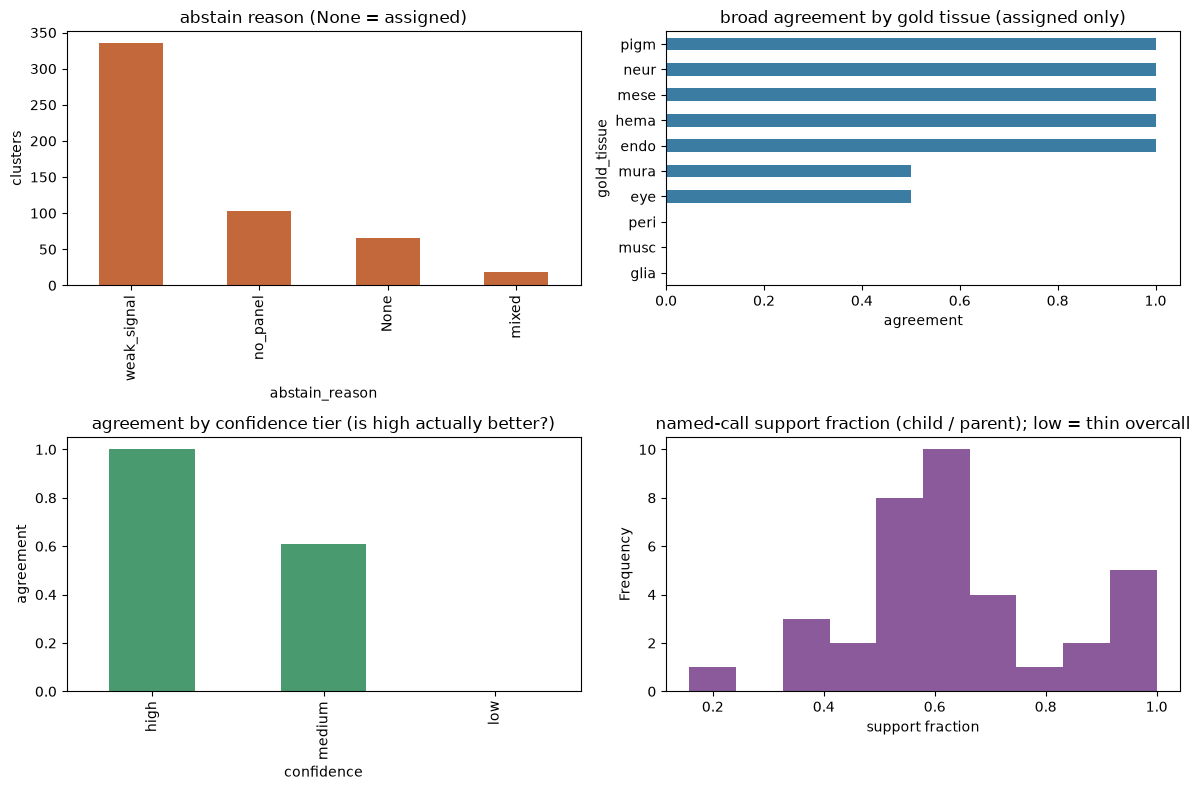

In [14]:
# DataFrame -> matplotlib (this is the one place a DataFrame genuinely earns its keep).
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# (a) abstain reasons — the coverage ceiling, decomposed.
df["abstain_reason"].value_counts(dropna=False).plot.bar(ax=ax[0, 0], color="#c2683a")
ax[0, 0].set_title("abstain reason (None = assigned)")
ax[0, 0].set_ylabel("clusters")

# (b) agreement by tissue (assigned only) — where the panels can and can't reach.
asg = df[df["agrees"].notna()]
by_t = asg.groupby("gold_tissue")["agrees"].agg(["mean", "size"]).sort_values("mean")
by_t["mean"].plot.barh(ax=ax[0, 1], color="#3a7ca2")
ax[0, 1].set_title("broad agreement by gold tissue (assigned only)")
ax[0, 1].set_xlabel("agreement")

# (c) confidence calibration — is "high" actually better than "low"?
cal = asg.groupby("confidence")["agrees"].mean().reindex(["high", "medium", "low"])
cal.plot.bar(ax=ax[1, 0], color="#4a9a6f")
ax[1, 0].set_title("agreement by confidence tier (is high actually better?)")
ax[1, 0].set_ylabel("agreement")

# (d) overcall support fraction — low = thin overcall (now just 1 of 36).
df["support_fraction"].dropna().plot.hist(ax=ax[1, 1], bins=10, color="#8a5a9a")
ax[1, 1].set_title("named-call support fraction (child / parent); low = thin overcall")
ax[1, 1].set_xlabel("support fraction")

plt.tight_layout()
plt.show()

The four panels together are the story: a **coverage** problem (panels a, b — most clusters get no
usable panel) is now the dominant ceiling. The over-precision that thin support fractions would reveal is absent — panel d sits high and only
one named call is thin (Sections 4, 5c).
Panel c is the reassurance that the confidence rubric is at least ordered. Section 7 previews the
remaining coverage lever.

## 7. A light what-if preview — read-only, engine unchanged

This does **not** change the engine. It recomputes, from the raw per-term tally, what a different
*gate* would surface — to inform a later 4c (tuning).

The descent already ranks support-aware: each step is chosen by `support × IC` with support the
dominant signal, which is why the overcall audit is 1/36. So the remaining lever is **coverage**, not
ranking:

- **Gate — `CONVERGENCE_MIN`.** A term needs at least `CONVERGENCE_MIN` (= 3) distinct genes to be
  eligible. Lowering it to 2 would surface more terms (more coverage on today's abstentions) — but
  2-gene evidence is thin, so the question for 4c is whether it adds *signal* or just *noise*. We
  preview how many abstentions would gain a 2-gene term.

**What to look for:** of 20 sampled `weak_signal` abstentions, how many would gain a
2-gene convergent term if the gate dropped from 3 to 2. A high count means real coverage upside —
but every gained term is 2-gene-thin, so it is a lever to test in 4c, not a fix to apply here.

In [15]:
def best_term_at_min(cluster_id, min_genes):
    """Read-only: count ZFA terms that clear a gene floor, plus the stoplist and IC-floor filter.

    Replays the raw tally (evaluate._replay_tally) and counts terms with at least min_genes distinct
    genes that are not on the STOPLIST and clear INFORMATION_CONTENT_MIN -- a rough preview of the
    coverage a lower gene floor (2 instead of CONVERGENCE_MIN=3) would surface. The live engine names
    by the descent's support floors, not by an IC gate, so this is a coarse upper bound.

    Args:
        cluster_id (str): A benchmark cluster id.
        min_genes (int): The gene floor to test (e.g. 2 instead of the live CONVERGENCE_MIN=3).

    Returns:
        int: Number of eligible terms at that floor.
    """
    row = next(b for b in benchmark if b.cluster_id == cluster_id)
    symbols = [next(iter(nm.symbols)) for nm in normalize_markers(row.markers, resources.synonyms) if nm.status == STATUS_RESOLVED]
    tally = evaluate._replay_tally(symbols, resources.expression_map, resources.zfa_ontology)
    from zlabel.resolve import STOPLIST
    return sum(
        1 for term_id, genes in tally.items()
        if len(genes) >= min_genes and term_id not in STOPLIST
        and resources.information_content.get(term_id, 0.0) >= INFORMATION_CONTENT_MIN
    )

# Preview lever 2: of 20 sampled weak_signal abstentions, how many gain a 2-gene convergent term?
sample = df[df["abstain_reason"] == "weak_signal"]["cluster_id"].head(20)
gained = sum(best_term_at_min(c, 2) > 0 for c in sample)
console.print(
    f"lever 2 preview: of [bold]20[/] sampled weak_signal abstentions, "
    f"[yellow]{gained}[/] would gain a 2-gene convergent term "
    f"(vs the live {CONVERGENCE_MIN}-gene gate)."
)
console.print("[dim]more coverage, but 4c must check the extra terms are signal, not noise.[/]")

lever 2 preview: of 20 sampled weak_signal abstentions, 20 would gain a 2-gene convergent term (vs the live 3-gene 
gate).

more coverage, but 4c must check the extra terms are signal, not noise.

## 8. Explore it yourself — `inspect()` any cluster

`inspect(cluster_id)` renders the full trace for **any** cluster as a colour-coded `rich` panel:
markers, normalization, panel scores, the descent's terminal term, the decision, the agreement score,
and the overcall audit. It is the workbench's main verb — combine it with `show_panel_scores`
(Section 5a) to investigate anything the aggregates flag.

**What to look for:** below we inspect the running example (an agreer) and the worst overcall side by
side — the same two clusters Sections 3–4 unfolded, now in one compact view. Then a **pick-any-cluster**
cell you can edit to point at any of the 522 ids.

In [16]:
from rich.panel import Panel as RichPanel

def inspect(cluster_id):
    """Explorer: the full, colour-coded trace for one cluster, as a rich panel.

    The poke-around verb of this workbench. Shows markers + normalization, top identity panels, the
    descent's terminal term, the decision, the broad-agreement score, and the overcall audit.
    Colour: the kind / agree / thin verdicts use the notebook's green-yellow-red-dim key.

    Args:
        cluster_id (str): Any benchmark cluster id (e.g. "neur.12", "glia.11").
    """
    o = oc[cluster_id]
    row = next(b for b in benchmark if b.cluster_id == cluster_id)
    normalized = normalize_markers(row.markers, resources.synonyms)
    symbols = [next(iter(nm.symbols)) for nm in normalized if nm.status == STATUS_RESOLVED]
    scores = [s for s in score_markers(normalized, resources.panels) if s.kind == "identity"]
    top = next((s for s in scores if s.score > 0), None)
    anchor = resources.anchors.get(top.bucket, frozenset()) if top else frozenset()
    votes = resolve_label(symbols, expression_map=resources.expression_map, zfa_ontology=resources.zfa_ontology,
                          information_content=resources.information_content, anchor=anchor)

    kind_colour = {"named": "green", "fallback": "yellow", "rollup": "yellow", "abstain": "dim"}[o.kind]
    agree_cell = "[green]True[/]" if o.agrees else "[red]False[/]" if o.agrees is False else "[dim]— (abstain/rollup/not_scored)[/]"

    body = Table.grid(padding=(0, 2))
    body.add_column(style="bold cyan", justify="right"); body.add_column()
    body.add_row("gold tissue", f"{o.gold_tissue} ({o.tissue_name})   stage {o.stage_hpf} hpf")
    body.add_row("markers", f"{row.markers[:10]}  ({o.n_resolved}/{len(row.markers)} resolved)")
    body.add_row("top panels", str([(s.bucket, round(s.score, 3)) for s in scores[:4]]))
    body.add_row("descent (terminal)", str([(v.zfa_name, round(v.information_content, 2), len(v.genes)) for v in votes]) or "no convergent term")
    body.add_row("decision", f"kind=[{kind_colour}]{o.kind}[/]  bucket=[{kind_colour}]{o.bucket!r}[/]  zfa_id={o.zfa_id}  depth={o.depth}")
    body.add_row("confidence", f"{o.confidence}   abstain_reason={o.abstain_reason}")
    body.add_row("agrees", agree_cell)
    if o.audit:
        a = o.audit
        thin = "[red]True[/]" if a.thin_support_overcall else "[green]False[/]"
        body.add_row("overcall audit", f"named {a.named_support} genes vs parent {a.parent_name!r} {a.parent_support}"
                                        f"  -> fraction {a.support_fraction:.2f}  thin={thin}")
    console.print(RichPanel(body, title=f"[bold]inspect({cluster_id!r})[/]", border_style=kind_colour))

# The running example (an agreer) and the worst overcall, side by side.
inspect(example.cluster_id)
inspect(min(named, key=lambda o: o.audit.support_fraction).cluster_id)

╭────────────────────────────────────────────── inspect('endo.22') ───────────────────────────────────────────────╮
│        gold tissue  endo (endoderm)   stage 84.0 hpf                                                            │
│            markers  ['prss1', 'prss59.2', 'fep15', 'erp27', 'pdia2', 'ctrb1', 'cpb1', 'CELA1 (1 of many)',      │
│                     'cpa5', 'apoda.2']  (23/25 resolved)                                                        │
│         top panels  [('pancreas', 0.178), ('blood_erythroid', 0.0), ('blood_lymphoid', 0.0), ('cardiac', 0.0)]  │
│ descent (terminal)  [('pancreas', 5.11, 11)]                                                                    │
│           decision  kind=named  bucket='pancreas'  zfa_id=ZFA:0000140  depth=7                                  │
│         confidence  medium   abstain_reason=None                                                                │
│             agrees  True                                                                                        │
│     overcall audit  named 11 genes vs parent 'compound organ' 14  -> fraction 0.79  thin=False                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── inspect('musc.19') ───────────────────────────────────────────────╮
│        gold tissue  musc (muscle)   stage 24.0 hpf                                                              │
│            markers  ['col1a2', 'mfap2', 'col5a1', 'mdka', 'tpm4a', 'postnb', 'cd81a', 'si:dkey-151g10.6',       │
│                     'vwde', 'pmp22a']  (24/25 resolved)                                                         │
│         top panels  [('mesenchyme', 0.184), ('blood_erythroid', 0.0), ('blood_lymphoid', 0.0), ('cardiac',      │
│                     0.0)]                                                                                       │
│ descent (terminal)  [('segmental plate', 4.32, 3)]                                                              │
│           decision  kind=named  bucket='segmental plate'  zfa_id=ZFA:0000279  depth=7                           │
│         confidence  low   abstain_reason=None                                                                   │
│             agrees  False                                                                                       │
│     overcall audit  named 3 genes vs parent 'portion of tissue' 19  -> fraction 0.16  thin=True                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [17]:
# ============================================================================
# PICK ANY CLUSTER — edit cluster_id and re-run to explore any of the 522 ids.
# Examples: a fallback that agrees ("mese.2"), a periderm miss ("peri.16"),
#           a no_panel abstention ("axia.10"). Companion: show_panel_scores(id).
# ============================================================================
cluster_id = "peri.16"   # <-- change me
inspect(cluster_id)
show_panel_scores(cluster_id)

╭────────────────────────────────────────────── inspect('peri.16') ───────────────────────────────────────────────╮
│        gold tissue  peri (periderm)   stage 18.0 hpf                                                            │
│            markers  ['krt4', 'krt92', 'cyt1', 'wu:fb18f06', 'krt5', 'lye', 'cyt1l', 'anxa1c', 'krt17', 'tmsb1'] │
│                     (22/25 resolved)                                                                            │
│         top panels  [('epidermis', 0.228), ('blood_erythroid', 0.0), ('blood_lymphoid', 0.0), ('cardiac', 0.0)] │
│ descent (terminal)  [('epidermis', 5.08, 9)]                                                                    │
│           decision  kind=named  bucket='epidermis'  zfa_id=ZFA:0000105  depth=6                                 │
│         confidence  medium   abstain_reason=None                                                                │
│             agrees  False                                                                                       │
│     overcall audit  named 9 genes vs parent 'epithelium' 14  -> fraction 0.64  thin=False                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

 peri.16  ·  gold peri  ·  abstain_reason=None 
┏━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ panel           ┃ score ┃ matched markers   ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ epidermis       │ 0.228 │ krt4, krt5, cldne │
│ blood_erythroid │ 0.000 │ —                 │
│ blood_lymphoid  │ 0.000 │ —                 │
│ cardiac         │ 0.000 │ —                 │
│ cartilage       │ 0.000 │ —                 │
│ endoderm_gut    │ 0.000 │ —                 │
└─────────────────┴───────┴───────────────────┘

## Synthesis — where the leverage is (questions for the next phase, not answers)

Ordered by how much each would move the numbers:

1. **Panel coverage is the ceiling.** ~18% of clusters get *no* panel hit and another ~66% hit a
   panel too weakly — together ~87% abstention (Sections 5–5a). The 33-panel set reaches 15 of the 19
   scored Daniocell tissues with at least one committed call, but many covered tissues' panels are
   still narrow. *Question for 4c: expand/curate panels (or learn them from a reference atlas) before
   anything else?*
2. **The descent (almost) never overcalls.** Only 1 of 36 named calls is a thin-support overcall
   (Sections 4 and 5c): the support-weighted descent earns its specificity instead of chasing the
   rarest term. The open question now is calibration, not
   ranking.
3. **Conservative abstention is honest, not a bug.** The engine rarely commits wrongly with high
   confidence; it mostly declines. That is the right failure mode for a layer-1 tool — the work is
   to *earn* more confident calls, not to force them.

**What's next — Phase 4c.** Use these measurements to drive panel expansion, and add a finer-labeled
reference (ZSCAPE/Zebrahub) so within-tissue depth can be *validated*, not just audited. Nothing here
changed the engine — 4b measures; 4c tunes. The exploration tools (`inspect`, `show_panel_scores`,
`best_term_at_min`) carry forward as the bench for trying those changes.